# NAVYA — Boosting Learning-Curve Diagnostic

This notebook diagnoses how validation loss changes across the boosting rounds in the XGBRegressor configuration already selected by Notebook 05. In XGBoost, each added tree is one boosting round; this is not an epoch-based neural-network training loop. The experiment predicts **only** `next_cycle_length_days`.

## 1. Imports, feature contract, and woman-wise partitions

This cell loads the model-ready dataset and exactly recreates the deterministic 800/100/100 woman split. Test women are retained untouched; Notebook 05 has already selected the XGBoost configuration using grouped CV.

In [7]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

RANDOM_STATE = 42
ROOT = Path.cwd().resolve()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
FEATURES = [
    "age_years",
    "menarche_age",
    "height_cm",
    "weight_kg",
    "bmi",
    "sleep_hours",
    "stress_level",
    "exercise_frequency",
    "uses_medication_or_contraceptive",
    "prev_cycle_1",
    "prev_cycle_2",
    "prev_cycle_3",
    "avg_previous_cycle_length",
    "std_previous_cycle_length",
    "prev_period_1",
    "prev_period_2",
    "prev_period_3",
    "avg_previous_period_length",
]
df = pd.read_csv(ROOT / "processed_data" / "model_ready_dataset.csv")
women = np.random.RandomState(RANDOM_STATE).permutation(
    np.sort(df["woman_id"].unique())
)
assert len(women) == 1000
train = df[df.woman_id.isin(women[:800])].copy()
validation = df[df.woman_id.isin(women[800:900])].copy()
assert not (set(train.woman_id) & set(validation.woman_id))
print(f"Rows — train: {len(train):,}; validation: {len(validation):,}")
print("The final test women are deliberately not used in this diagnostic notebook.")

Rows — train: 16,000; validation: 2,000
The final test women are deliberately not used in this diagnostic notebook.


## 2. Fit the selected XGBoost model

We fit the exact number of trees selected by Notebook 05. The median imputer is learned from training women only. XGBoost records validation RMSE after every boosting round, which is squared to obtain validation MSE.

In [8]:
import json
with open(ROOT / "results" / "tuning" / "best_tuned_model.json") as f: selected = json.load(f)
assert selected["model"] == "XGBRegressor", "Run Notebook 05 first: this diagnostic follows the selected XGBRegressor configuration."
params = {key.replace("model__", ""): value for key, value in selected["best_params"].items()}
MAX_ITERATIONS = int(params.pop("n_estimators"))
X_train, y_train = train[FEATURES], train["next_cycle_length_days"]
X_val, y_val = validation[FEATURES], validation["next_cycle_length_days"]
imputer = SimpleImputer(strategy="median")
X_train_imputed = imputer.fit_transform(X_train)
X_val_imputed = imputer.transform(X_val)
estimator = XGBRegressor(
    n_estimators=MAX_ITERATIONS, random_state=RANDOM_STATE, n_jobs=-1,
    objective="reg:squarederror", eval_metric="rmse", **params,
)
estimator.fit(X_train_imputed, y_train, eval_set=[(X_val_imputed, y_val)], verbose=False)
model = Pipeline([("imputer", imputer), ("model", estimator)])
print(f"Fitted the authoritative XGBRegressor configuration for {MAX_ITERATIONS} boosting rounds on training women only.")

Fitted the authoritative XGBRegressor configuration for 250 boosting rounds on training women only.


## 3. Calculate validation loss at every boosting iteration

Validation MSE is recorded after tree 1 through the selected number of XGBoost boosting rounds. The lowest point is descriptive only: it does not replace Notebook 05's grouped-CV selection decision.

In [9]:
validation_rmse = np.asarray(estimator.evals_result()["validation_0"]["rmse"], dtype=float)
validation_mse = validation_rmse ** 2
lowest_observed_iteration = int(np.argmin(validation_mse) + 1)
lowest_observed_validation_mse = float(validation_mse[lowest_observed_iteration - 1])
loss_curve = pd.DataFrame(
    {
        "boosting_iteration": np.arange(1, MAX_ITERATIONS + 1),
        "validation_mse": validation_mse,
    }
)
display(loss_curve.head())
print(f"Authoritatively selected XGBoost boosting rounds (from Notebook 05): {MAX_ITERATIONS}")
print(f"Lowest diagnostic validation MSE occurs at iteration {lowest_observed_iteration}: {lowest_observed_validation_mse:.6f}")

,boosting_iteration,validation_mse
0,1,15.748374
1,2,15.031134
2,3,14.357333
3,4,13.730009
4,5,13.151107


Authoritatively selected XGBoost boosting rounds (from Notebook 05): 250
Lowest diagnostic validation MSE occurs at iteration 249: 2.664635


## 4. Visualise the selected model's learning curve

The blue curve is the real validation MSE after each XGBoost tree. The red dashed line marks the number of boosting rounds selected by grouped cross-validation in Notebook 05. It is not an independent optimum selected from this chart. `plt.show()` embeds the plot directly in this notebook when the cell is run.

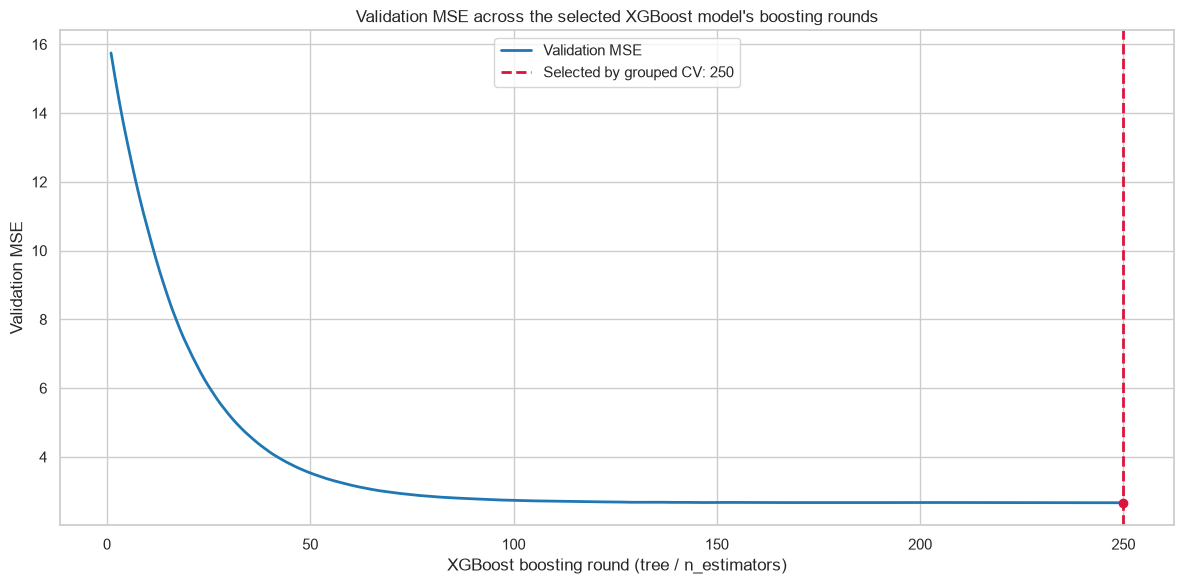

In [10]:
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(
    loss_curve["boosting_iteration"],
    loss_curve["validation_mse"],
    color="#1f77b4",
    linewidth=2,
    label="Validation MSE",
)
ax.axvline(
    MAX_ITERATIONS,
    color="crimson",
    linestyle="--",
    linewidth=2,
    label=f"Selected by grouped CV: {MAX_ITERATIONS}",
)
ax.scatter([MAX_ITERATIONS], [validation_mse[MAX_ITERATIONS - 1]], color="crimson", zorder=3)
ax.set(
    title="Validation MSE across the selected XGBoost model's boosting rounds",
    xlabel="XGBoost boosting round (tree / n_estimators)",
    ylabel="Validation MSE",
)
ax.legend()
plt.tight_layout()
plt.show()

##  Training vs Validation RMSE Across Boosting Rounds

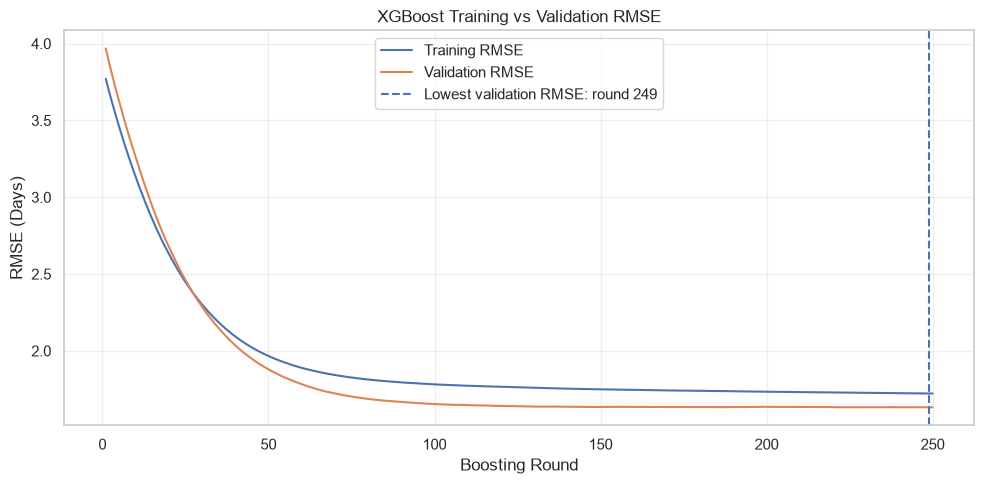

Lowest validation RMSE: 1.6324 days
Observed at boosting round: 249
Selected boosting rounds from Notebook 05: 250


In [11]:
# ============================================================
# Training vs Validation RMSE Across Boosting Rounds
# ============================================================

# Refit the same tuned XGBoost configuration only for diagnostics,
# recording both training and validation error after each boosting round.

diagnostic_estimator = XGBRegressor(
    n_estimators=MAX_ITERATIONS,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    objective="reg:squarederror",
    eval_metric="rmse",
    **params,
)

diagnostic_estimator.fit(
    X_train_imputed,
    y_train,
    eval_set=[
        (X_train_imputed, y_train),
        (X_val_imputed, y_val),
    ],
    verbose=False,
)

# Extract RMSE at every boosting round
eval_results = diagnostic_estimator.evals_result()

train_rmse = np.asarray(
    eval_results["validation_0"]["rmse"],
    dtype=float
)

val_rmse = np.asarray(
    eval_results["validation_1"]["rmse"],
    dtype=float
)

iterations = np.arange(1, MAX_ITERATIONS + 1)

# Find the lowest validation RMSE
best_iteration = int(np.argmin(val_rmse) + 1)
best_val_rmse = float(val_rmse[best_iteration - 1])

# Plot
plt.figure(figsize=(10, 5))

plt.plot(
    iterations,
    train_rmse,
    label="Training RMSE"
)

plt.plot(
    iterations,
    val_rmse,
    label="Validation RMSE"
)

plt.axvline(
    best_iteration,
    linestyle="--",
    label=f"Lowest validation RMSE: round {best_iteration}"
)

plt.xlabel("Boosting Round")
plt.ylabel("RMSE (Days)")
plt.title("XGBoost Training vs Validation RMSE")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

print(f"Lowest validation RMSE: {best_val_rmse:.4f} days")
print(f"Observed at boosting round: {best_iteration}")
print(f"Selected boosting rounds from Notebook 05: {MAX_ITERATIONS}")

## 5. Validation-only diagnostic summary

This notebook does not select another configuration and does not access test women. It reports the validation curve for the configuration already selected by Notebook 05; Notebook 09 performs the one final held-out test evaluation.

In [12]:
metrics = {
    "selected_boosting_iteration": MAX_ITERATIONS,
    "initial_validation_mse": float(validation_mse[0]),
    "selected_iteration_validation_mse": float(validation_mse[MAX_ITERATIONS - 1]),
    "lowest_diagnostic_validation_mse": lowest_observed_validation_mse,
    "lowest_diagnostic_iteration": lowest_observed_iteration,
}
display(pd.DataFrame([metrics]).round(6))

,selected_boosting_iteration,initial_validation_mse,selected_iteration_validation_mse,lowest_diagnostic_validation_mse,lowest_diagnostic_iteration
0,250,15.748374,2.665449,2.664635,249


## 6. Save reproducible XGBoost learning-curve artifacts

The CSV contains every plotted iteration and the JSON captures the grouped-CV-selected iteration plus validation diagnostics. The final test set is reserved exclusively for Notebook 09.

In [13]:
import json

metrics_dir = ROOT / "results" / "metrics"
plots_dir = ROOT / "results" / "plots"
metrics_dir.mkdir(parents=True, exist_ok=True)
plots_dir.mkdir(parents=True, exist_ok=True)
loss_curve.to_csv(metrics_dir / "xgb_learning_curve.csv", index=False)
with open(metrics_dir / "xgb_learning_curve_diagnostic.json", "w") as f:
    json.dump(metrics, f, indent=2)
fig.savefig(plots_dir / "xgb_learning_curve.png", dpi=180, bbox_inches="tight")
print("Saved XGBoost learning-curve CSV, metrics JSON, and PNG plot.")

Saved XGBoost learning-curve CSV, metrics JSON, and PNG plot.


## Interpretation

A decreasing validation-MSE curve means added XGBoost trees improve validation performance. If the curve rises after its minimum, later trees may be beginning to overfit this validation set. The red line marks the number of boosting rounds selected by grouped CV in Notebook 05; this chart does not independently choose a new value.